# Análisis y Preparación de Datos: Ejemplo Aplicado de Manchas Solares

Este notebook es un ejemplo aplicado de **Análisis y Preparación de Datos** en el contexto de la Ingeniería Mecatrónica. Se realiza una limpieza exhaustiva, análisis comparativo, reducción de dimensionalidad (PCA) y detección de outliers sobre un dataset de clasificación McIntosh de manchas solares.

**Etapas clave:**
1. Carga y Limpieza inicial de nulos.
2. Normalización Min-Max [0, 1] de metadatos (parámetros físicos).
3. Análisis de componentes principales (PCA).
4. Detección y retiro de outliers.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from mpl_toolkits.mplot3d import Axes3D

# Configuración de estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga y Limpieza Inicial

In [17]:
df_raw = pd.read_csv('sunspot_data.csv')

# Limpieza de nulos
df = df_raw.dropna(axis=0, how='any').copy()
df = df.dropna(axis=1, how='all')

# Ingeniería de características
df['mc_Z'] = df['mcintosh_full'].str[0]
df['mc_P'] = df['mcintosh_full'].str[1]
df['mc_C'] = df['mcintosh_full'].str[2]

print(f"Dataset cargado y limpio de nulos. Registros: {df.shape[0]}")

Dataset cargado y limpio de nulos. Registros: 12045


## 2. Visualización: Distribuciones Iniciales (Antes de Limpieza Final)

En esta sección visualizamos la frecuencia de las clases McIntosh de forma independiente y destacada.

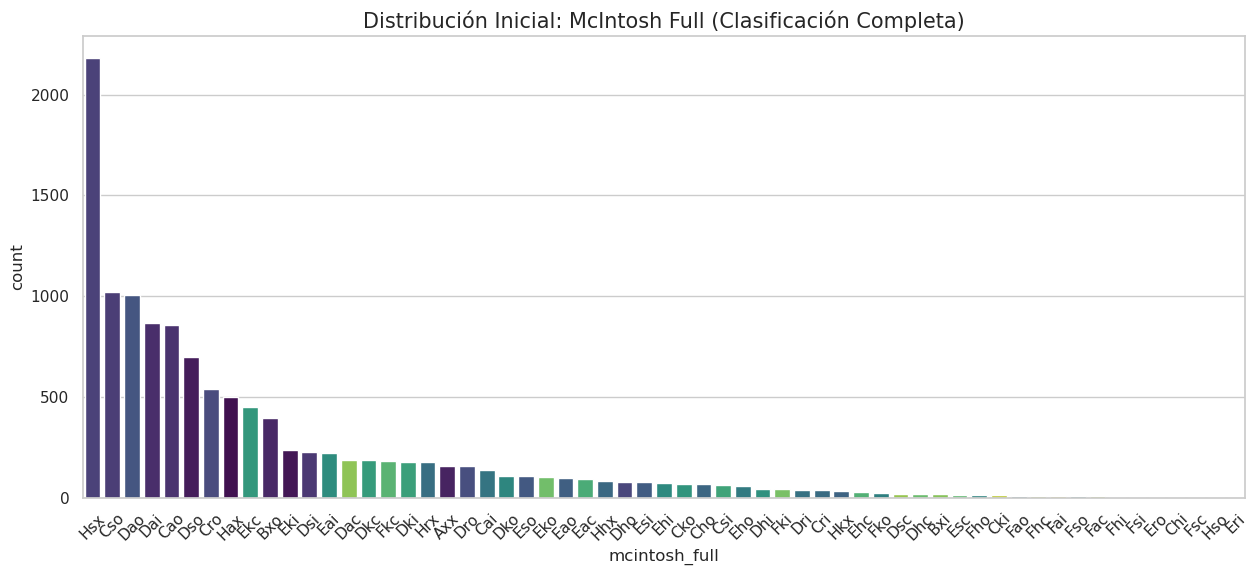

In [18]:
# 2.1 Distribución de McIntosh Full (Combinado)
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='mcintosh_full', hue='mcintosh_full', legend=False, 
              order=df['mcintosh_full'].value_counts().index, palette='viridis')
plt.title('Distribución Inicial: McIntosh Full (Clasificación Completa)', fontsize=15)
plt.xticks(rotation=45)
plt.show()

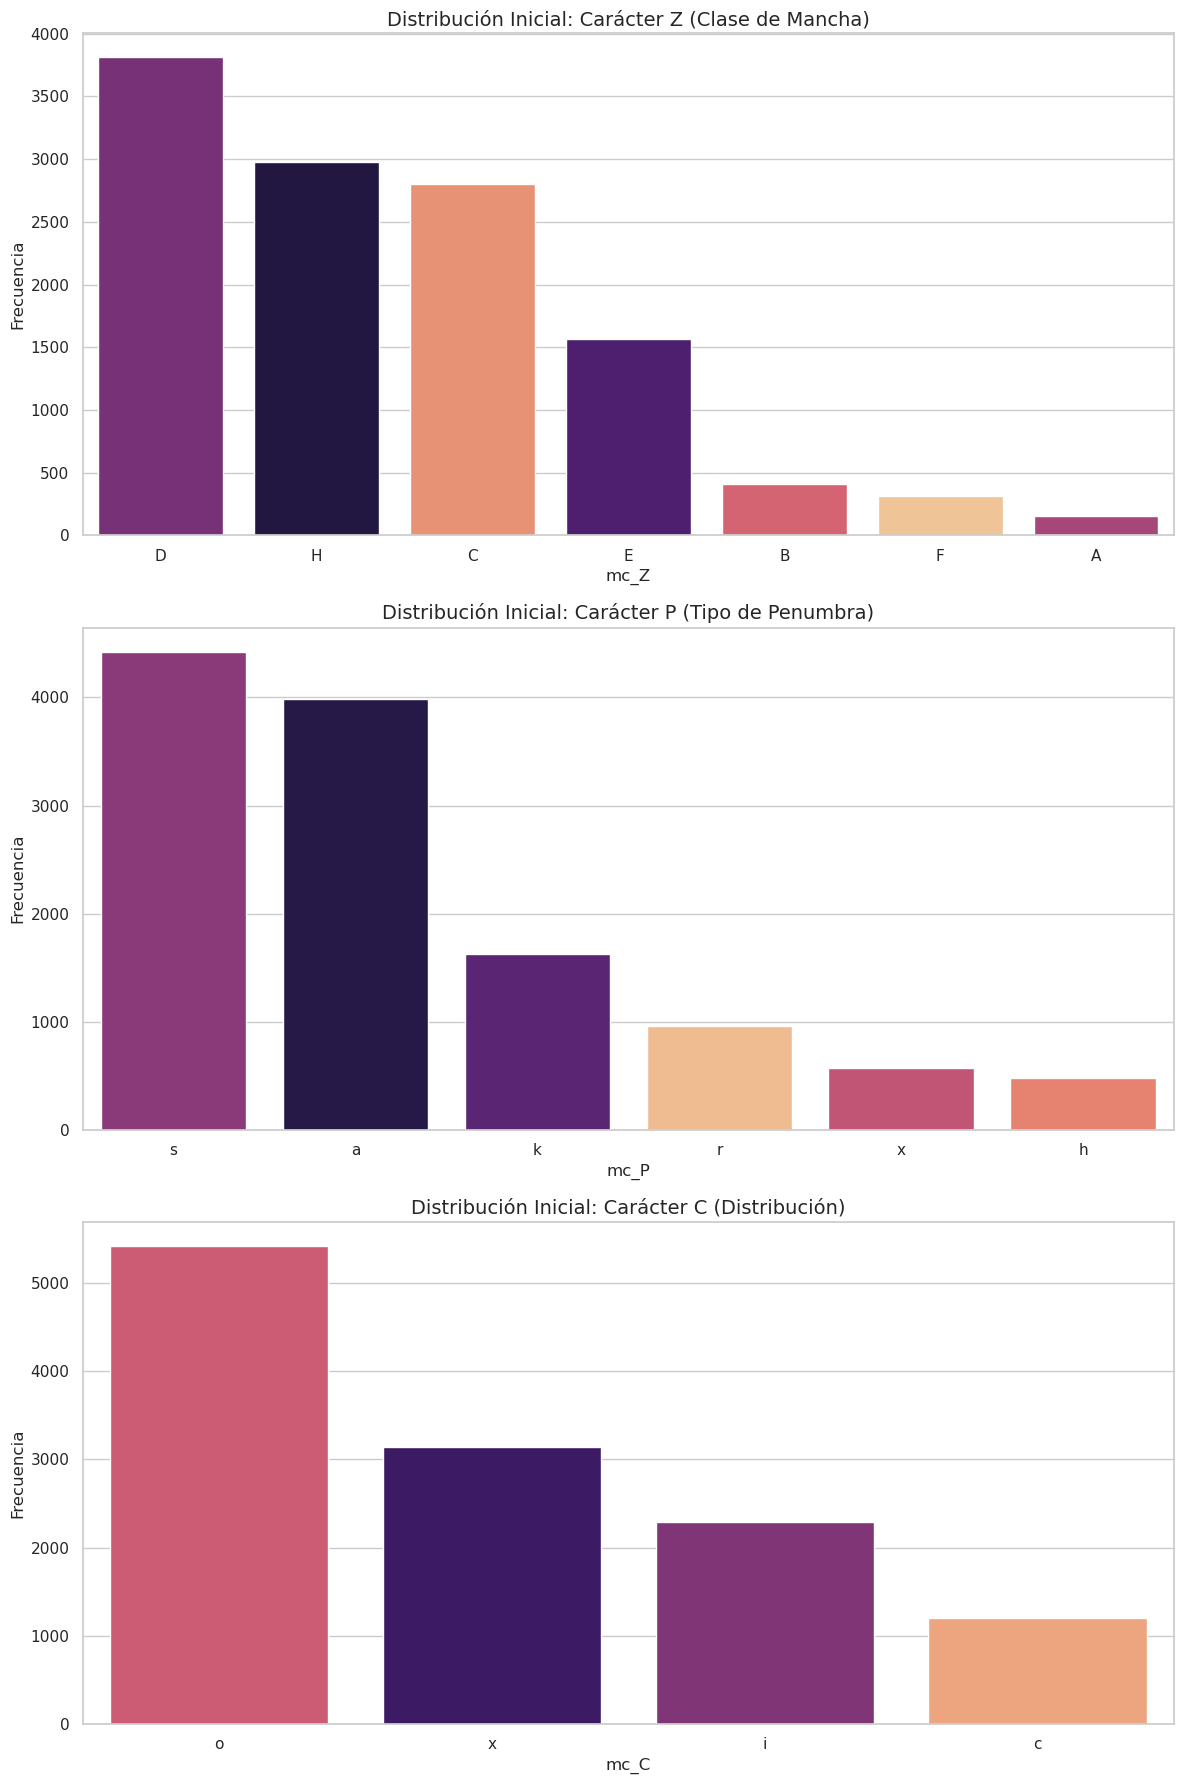

In [19]:
# 2.2 Distribución de Caracteres Individuales
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
chars = [('mc_Z', 'Z (Clase de Mancha)'), ('mc_P', 'P (Tipo de Penumbra)'), ('mc_C', 'C (Distribución)')]

for i, (col, label) in enumerate(chars):
    sns.countplot(data=df, x=col, hue=col, legend=False, ax=axes[i], 
                  order=df[col].value_counts().index, palette='magma')
    axes[i].set_title(f'Distribución Inicial: Carácter {label}', fontsize=14)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3. Normalización Min-Max [0, 1] de Metadatos

Escalamos los parámetros físicos al rango [0, 1] para uniformizar las entradas.

In [20]:
features = ['area', 'dist_angular', 'z_length_deg', 'num_spots_det', 'area_total', 
            'fill_ratio', 'elongation', 'pen_diam_ns_deg', 'pen_symmetry', 'pen_irregularity']

X = df[features]

# Normalización Min-Max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Visualización de datos normalizados
df_norm = pd.DataFrame(X_scaled, columns=features)
print("Metadatos normalizados en rango [0, 1]:")
display(df_norm.head())
print(f"Mínimo global: {df_norm.min().min()}, Máximo global: {df_norm.max().max()}")

Metadatos normalizados en rango [0, 1]:


,area,dist_angular,z_length_deg,num_spots_det,area_total,fill_ratio,elongation,pen_diam_ns_deg,pen_symmetry,pen_irregularity
0,0.036364,0.876906,0.036026,0.066667,0.015817,0.631252,0.051907,0.0,0.0,0.0
1,0.149091,0.279489,0.309742,0.133333,0.062390,0.074777,0.271587,0.0,0.0,0.0
2,0.040000,0.695364,0.021455,0.066667,0.009666,0.748581,0.063469,0.0,0.0,0.0
3,0.025455,0.723857,0.022096,0.066667,0.009666,0.748581,0.063469,0.0,0.0,0.0
4,0.000000,0.351303,0.017752,0.066667,0.006151,0.497161,0.063469,0.0,0.0,0.0


Mínimo global: 0.0, Máximo global: 1.0000000000000002


## 4. Estadísticos Agrupados Estilizados

In [21]:
stats_summary = df.groupby('mcintosh_full')[features].mean()
print("Medias por Clase (Datos Originales):")
try:
    display(stats_summary.style.background_gradient(cmap='YlGnBu').format("{:.2f}"))
except Exception:
    display(stats_summary)

Medias por Clase (Datos Originales):


,area,dist_angular,z_length_deg,num_spots_det,area_total,fill_ratio,elongation,pen_diam_ns_deg,pen_symmetry,pen_irregularity
mcintosh_full,,,,,,,,,,
Axx,9.75,35.94,1.88,0.39,37.39,0.41,1.20,0.16,0.14,0.21
Bxi,17.65,33.88,4.67,0.71,55.94,0.22,2.38,0.23,0.22,0.35
Bxo,14.39,37.37,2.77,0.48,47.01,0.34,1.51,0.32,0.21,0.38
Cai,101.43,33.88,3.59,1.21,64.70,0.27,1.62,0.33,0.18,0.40
Cao,76.75,37.75,2.48,0.94,39.90,0.36,1.35,0.16,0.11,0.21
Chi,273.33,39.90,2.40,1.00,112.67,0.48,1.29,0.00,0.00,0.00
Cho,314.17,37.94,2.35,1.11,109.08,0.47,0.97,0.09,0.06,0.13
Cki,335.45,33.82,3.11,1.91,100.36,0.30,1.07,0.48,0.11,0.31
Cko,363.62,42.91,2.85,1.33,104.87,0.41,1.07,0.18,0.11,0.27


## 5. PCA y Detección de Outliers

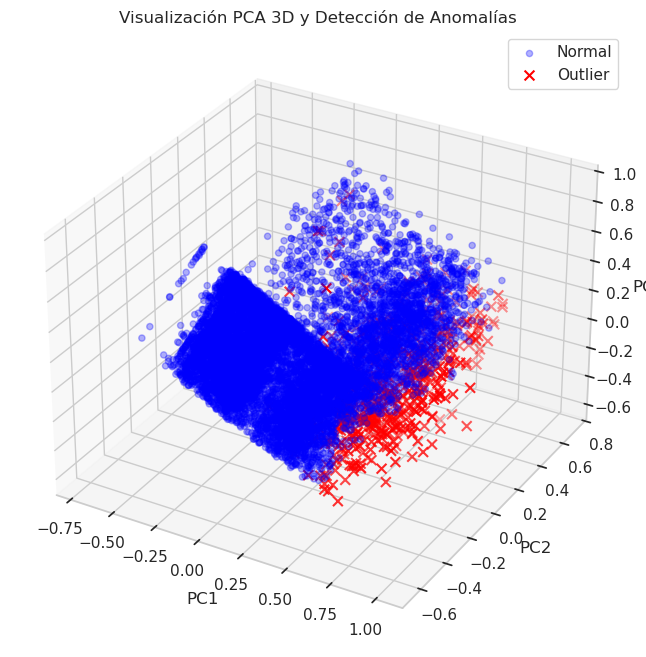

In [22]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

iso = IsolationForest(contamination=0.05, random_state=42)
df['outlier'] = iso.fit_predict(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[df['outlier'] == 1, 0], X_pca[df['outlier'] == 1, 1], X_pca[df['outlier'] == 1, 2], 
           c='blue', alpha=0.3, label='Normal')
ax.scatter(X_pca[df['outlier'] == -1, 0], X_pca[df['outlier'] == -1, 1], X_pca[df['outlier'] == -1, 2], 
           c='red', marker='x', s=50, label='Outlier')
ax.set_title('Visualización PCA 3D y Detección de Anomalías')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.legend()
plt.show()

## 6. Resultados Finales: Dataset Limpio y Sin Outliers

Limpieza completada. Dataset final: 11442 registros.


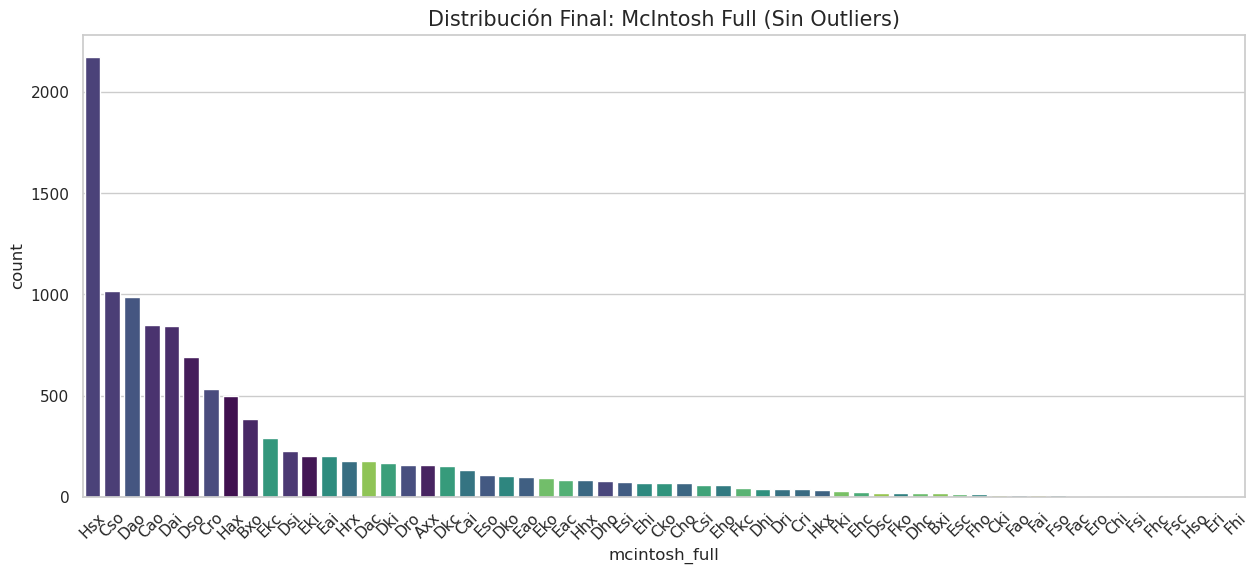

In [23]:
df_clean = df[df['outlier'] == 1].copy()
print(f"Limpieza completada. Dataset final: {df_clean.shape[0]} registros.")

# Histograma Final Destacado
plt.figure(figsize=(15, 6))
sns.countplot(data=df_clean, x='mcintosh_full', hue='mcintosh_full', legend=False, 
              order=df_clean['mcintosh_full'].value_counts().index, palette='viridis')
plt.title('Distribución Final: McIntosh Full (Sin Outliers)', fontsize=15)
plt.xticks(rotation=45)
plt.show()

In [24]:
df_clean.to_csv('sunspot_data_clean.csv', index=False)
print("Base de datos 'sunspot_data_clean.csv' generada con éxito.")

Base de datos 'sunspot_data_clean.csv' generada con éxito.
